In [1]:
# Cell 1 — Environment and GPU check

import importlib.util
import json
import math
import os
import random
import shutil
import subprocess
import sys
import tarfile
import time
import warnings
import zipfile
from collections import OrderedDict, defaultdict
from pathlib import Path

# Install nibabel only when the Kaggle image does not already contain it.
if importlib.util.find_spec("nibabel") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nibabel"])

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. Open Kaggle Notebook Settings and select "
        "Accelerator → GPU, then restart the session."
    )

DEVICE = torch.device("cuda")
AMP_ENABLED = True

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# Reproducible patient split and initialization.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Fixed image sizes make cuDNN benchmarking useful on Kaggle GPUs.
torch.backends.cudnn.benchmark = True


Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Cell 2 — Locate or extract the attached BraTS dataset

INPUT_ROOT = Path("/kaggle/input")
EXTRACT_ROOT = Path("/kaggle/working/brats_extracted")
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

print("Attached Kaggle inputs:")
for item in sorted(INPUT_ROOT.iterdir()):
    print("-", item.name)


def _find_file(patient_dir: Path, suffix: str):
    for extension in (".nii.gz", ".nii"):
        candidate = patient_dir / f"{patient_dir.name}_{suffix}{extension}"
        if candidate.exists():
            return candidate
    return None


def _patient_is_valid(patient_dir: Path) -> bool:
    if not patient_dir.is_dir() or not patient_dir.name.startswith("BraTS20_Training_"):
        return False

    flair = _find_file(patient_dir, "flair")
    seg = _find_file(patient_dir, "seg")

    # A small number of distributions contain an irregularly named mask.
    if seg is None:
        known = ("_flair.nii", "_t1.nii", "_t1ce.nii", "_t2.nii")
        for file in patient_dir.iterdir():
            name = file.name.lower()
            if file.is_file() and name.endswith((".nii", ".nii.gz")):
                if not any(token in name for token in known):
                    seg = file
                    break

    return flair is not None and seg is not None


def locate_brats_root(search_root: Path):
    valid_patients = []
    for patient_dir in search_root.rglob("BraTS20_Training_*"):
        if _patient_is_valid(patient_dir):
            valid_patients.append(patient_dir)

    if not valid_patients:
        return None

    parent_counts = defaultdict(int)
    for patient_dir in valid_patients:
        parent_counts[patient_dir.parent] += 1

    root = max(parent_counts, key=parent_counts.get)
    return root


def archive_looks_relevant(path: Path) -> bool:
    """Select a training archive or a wrapper containing a training archive."""
    try:
        if zipfile.is_zipfile(path):
            with zipfile.ZipFile(path, "r") as archive:
                names = [name.lower() for name in archive.namelist()]
        elif tarfile.is_tarfile(path):
            with tarfile.open(path, "r:*") as archive:
                names = [member.name.lower() for member in archive.getmembers()]
        else:
            return False
    except Exception:
        return False

    contains_segmentation = any("_seg.nii" in name for name in names)
    contains_training_archive = any(
        ("train" in name or "training" in name)
        and name.endswith((".zip", ".tar", ".tar.gz", ".tgz"))
        for name in names
    )
    return contains_segmentation or contains_training_archive


def extract_archive(path: Path, destination: Path):
    destination.mkdir(parents=True, exist_ok=True)
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path, "r") as archive:
            archive.extractall(destination)
    elif tarfile.is_tarfile(path):
        with tarfile.open(path, "r:*") as archive:
            archive.extractall(destination)
    else:
        raise ValueError(f"Unsupported archive: {path}")


BRATS_ROOT = locate_brats_root(INPUT_ROOT)

# Some Kaggle datasets store the actual MRI folders inside one or more ZIP files.
if BRATS_ROOT is None:
    processed_archives = set()

    for round_number in range(3):
        archive_paths = []
        for root in (INPUT_ROOT, EXTRACT_ROOT):
            archive_paths.extend(root.rglob("*.zip"))
            archive_paths.extend(root.rglob("*.tar"))
            archive_paths.extend(root.rglob("*.tar.gz"))
            archive_paths.extend(root.rglob("*.tgz"))

        new_archives = [
            path for path in archive_paths
            if str(path.resolve()) not in processed_archives
        ]

        if not new_archives:
            break

        # Prefer files whose names clearly indicate training data.
        new_archives.sort(
            key=lambda path: (
                "train" not in path.name.lower(),
                "brats" not in path.name.lower(),
                str(path),
            )
        )

        extracted_any = False
        for archive_path in new_archives:
            processed_archives.add(str(archive_path.resolve()))
            if not archive_looks_relevant(archive_path):
                continue

            destination = EXTRACT_ROOT / f"archive_{round_number}_{archive_path.stem}"
            print("Extracting:", archive_path)
            extract_archive(archive_path, destination)
            extracted_any = True

            BRATS_ROOT = locate_brats_root(EXTRACT_ROOT)
            if BRATS_ROOT is not None:
                break

        if BRATS_ROOT is not None or not extracted_any:
            break

if BRATS_ROOT is None:
    raise FileNotFoundError(
        "BraTS 2020 training patient folders were not found. Attach a dataset "
        "containing BraTS20_Training_* folders or a training ZIP that includes "
        "FLAIR images and segmentation masks."
    )

print("BraTS training root:", BRATS_ROOT)
print("Valid patient folders:", sum(_patient_is_valid(p) for p in BRATS_ROOT.glob("BraTS20_Training_*")))


Attached Kaggle inputs:
- datasets
BraTS training root: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Valid patient folders: 369


In [3]:
# Cell 3 — Project configuration

RUN_MODE = "final"            # Use "quick" for a short test, then return to "final".
IMAGE_SIZE = 128
BATCH_SIZE = 16
BASE_FILTERS = 16
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-5
NUM_WORKERS = 2
EARLY_STOPPING_PATIENCE = 3
NEGATIVE_TO_POSITIVE_RATIO = 1.0
MIN_BRAIN_PIXELS = 200

if RUN_MODE not in {"quick", "final"}:
    raise ValueError("RUN_MODE must be 'quick' or 'final'.")

if RUN_MODE == "quick":
    MAX_PATIENTS = 20
    NUM_EPOCHS = 2
else:
    MAX_PATIENTS = None
    NUM_EPOCHS = 10

WORK_ROOT = Path("/kaggle/working")
PROCESSED_ROOT = WORK_ROOT / f"brats_processed_{RUN_MODE}_{IMAGE_SIZE}"
OUTPUT_ROOT = WORK_ROOT / f"brats_2d_unet_outputs_{RUN_MODE}"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
RESULTS_DIR = OUTPUT_ROOT / "results"
FIGURE_DIR = OUTPUT_ROOT / "figures"

for directory in (PROCESSED_ROOT, OUTPUT_ROOT, CHECKPOINT_DIR, RESULTS_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "run_mode": RUN_MODE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "base_filters": BASE_FILTERS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "num_workers": NUM_WORKERS,
    "num_epochs": NUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "negative_to_positive_ratio": NEGATIVE_TO_POSITIVE_RATIO,
    "seed": SEED,
    "brats_root": str(BRATS_ROOT),
}

with (OUTPUT_ROOT / "configuration.json").open("w") as file:
    json.dump(CONFIG, file, indent=2)

print(json.dumps(CONFIG, indent=2))
print("Processed data:", PROCESSED_ROOT)
print("Project outputs:", OUTPUT_ROOT)


{
  "run_mode": "final",
  "image_size": 128,
  "batch_size": 16,
  "base_filters": 16,
  "learning_rate": 0.0002,
  "weight_decay": 1e-05,
  "num_workers": 2,
  "num_epochs": 10,
  "early_stopping_patience": 3,
  "negative_to_positive_ratio": 1.0,
  "seed": 42,
  "brats_root": "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
}
Processed data: /kaggle/working/brats_processed_final_128
Project outputs: /kaggle/working/brats_2d_unet_outputs_final


In [4]:
# Cell 4 — Discover patients and create a patient-level split


def patient_files(patient_dir: Path):
    flair_path = _find_file(patient_dir, "flair")
    seg_path = _find_file(patient_dir, "seg")

    if seg_path is None:
        known_modalities = {"flair", "t1", "t1ce", "t2"}
        for file in patient_dir.iterdir():
            name = file.name.lower()
            if not file.is_file() or not name.endswith((".nii", ".nii.gz")):
                continue
            is_known_modality = any(f"_{modality}.nii" in name for modality in known_modalities)
            if not is_known_modality:
                seg_path = file
                break

    if flair_path is None or seg_path is None:
        return None
    return flair_path, seg_path


cases = []
for patient_dir in sorted(BRATS_ROOT.glob("BraTS20_Training_*")):
    files = patient_files(patient_dir)
    if files is None:
        continue
    flair_path, seg_path = files
    cases.append(
        {
            "case_id": patient_dir.name,
            "flair_path": str(flair_path),
            "seg_path": str(seg_path),
        }
    )

if len(cases) < 10:
    raise RuntimeError(f"Only {len(cases)} valid patients were found; the attached dataset appears incomplete.")

random.Random(SEED).shuffle(cases)
if MAX_PATIENTS is not None:
    cases = cases[: min(MAX_PATIENTS, len(cases))]

n_cases = len(cases)
n_train = max(1, int(n_cases * 0.70))
n_val = max(1, int(n_cases * 0.15))
if n_train + n_val >= n_cases:
    n_val = max(1, n_cases - n_train - 1)

split = {
    "train": cases[:n_train],
    "val": cases[n_train:n_train + n_val],
    "test": cases[n_train + n_val:],
}

if not split["test"]:
    raise RuntimeError("The patient split produced no test patients.")

with (OUTPUT_ROOT / "patient_split.json").open("w") as file:
    json.dump(split, file, indent=2)

print("Total selected patients:", n_cases)
print("Train patients:", len(split["train"]))
print("Validation patients:", len(split["val"]))
print("Test patients:", len(split["test"]))
print("Example patient:", split["train"][0]["case_id"])


Total selected patients: 369
Train patients: 258
Validation patients: 55
Test patients: 56
Example patient: BraTS20_Training_298


In [5]:
# Cell 5 — Preprocess NIfTI volumes into cached 2D slices


def normalize_flair(volume: np.ndarray) -> np.ndarray:
    volume = volume.astype(np.float32)
    brain = volume > 0
    values = volume[brain]

    if values.size == 0:
        return np.zeros_like(volume, dtype=np.float32)

    mean = float(values.mean())
    std = float(values.std())
    if std < 1e-8:
        std = 1.0

    normalized = np.zeros_like(volume, dtype=np.float32)
    normalized[brain] = (volume[brain] - mean) / std
    normalized = np.clip(normalized, -5.0, 5.0)
    return normalized


def resize_stack(images: np.ndarray, masks: np.ndarray):
    image_tensor = torch.from_numpy(images).unsqueeze(1).float()
    mask_tensor = torch.from_numpy(masks).unsqueeze(1).float()

    resized_images = F.interpolate(
        image_tensor,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(1).numpy()

    resized_masks = F.interpolate(
        mask_tensor,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="nearest",
    ).squeeze(1).numpy()

    resized_masks = (resized_masks >= 0.5).astype(np.uint8)
    return resized_images.astype(np.float16), resized_masks


def choose_slices(flair: np.ndarray, tumour: np.ndarray, mode: str, case_seed: int):
    brain_slices = [
        z for z in range(flair.shape[2])
        if int((flair[:, :, z] != 0).sum()) >= MIN_BRAIN_PIXELS
    ]
    positive = [z for z in brain_slices if tumour[:, :, z].any()]
    negative = [z for z in brain_slices if not tumour[:, :, z].any()]

    if mode == "train":
        rng = random.Random(case_seed)
        number_of_negatives = min(
            len(negative),
            int(round(len(positive) * NEGATIVE_TO_POSITIVE_RATIO)),
        )
        sampled_negative = rng.sample(negative, number_of_negatives) if number_of_negatives else []
        selected = positive + sampled_negative
        rng.shuffle(selected)
    else:
        selected = brain_slices

    return selected


def preprocess_split(split_name: str, split_cases: list):
    output_directory = PROCESSED_ROOT / split_name
    output_directory.mkdir(parents=True, exist_ok=True)
    manifest = []

    for case_index, case in enumerate(tqdm(split_cases, desc=f"Preprocessing {split_name}")):
        flair_img = nib.load(case["flair_path"])
        seg_img = nib.load(case["seg_path"])
        flair = np.asarray(flair_img.dataobj, dtype=np.float32)
        seg = np.asarray(seg_img.dataobj)

        if flair.shape != seg.shape:
            raise ValueError(
                f"Shape mismatch for {case['case_id']}: FLAIR {flair.shape}, mask {seg.shape}"
            )

        normalized = normalize_flair(flair)
        whole_tumour = np.isin(seg, [1, 2, 4]).astype(np.uint8)
        selected_slices = choose_slices(
            normalized,
            whole_tumour,
            mode=split_name,
            case_seed=SEED + case_index,
        )

        if not selected_slices:
            print("Skipping patient with no usable slices:", case["case_id"])
            continue

        image_stack = np.stack([normalized[:, :, z] for z in selected_slices])
        mask_stack = np.stack([whole_tumour[:, :, z] for z in selected_slices])
        image_stack, mask_stack = resize_stack(image_stack, mask_stack)
        has_tumour = mask_stack.reshape(mask_stack.shape[0], -1).any(axis=1).astype(np.uint8)

        save_path = output_directory / f"{case['case_id']}.npz"
        np.savez_compressed(
            save_path,
            images=image_stack,
            masks=mask_stack,
            slice_indices=np.asarray(selected_slices, dtype=np.int16),
            has_tumour=has_tumour,
        )

        manifest.append(
            {
                "case_id": case["case_id"],
                "file": str(save_path),
                "num_slices": int(len(selected_slices)),
                "tumour_slices": int(has_tumour.sum()),
            }
        )

    return manifest


manifest_path = PROCESSED_ROOT / "manifest.json"
expected_directories = [PROCESSED_ROOT / name for name in ("train", "val", "test")]
processed_files_exist = all(directory.exists() and any(directory.glob("*.npz")) for directory in expected_directories)

if manifest_path.exists() and processed_files_exist:
    print("Processed slices already exist. Skipping preprocessing.")
    with manifest_path.open() as file:
        manifests = json.load(file)
else:
    manifests = {
        name: preprocess_split(name, split[name])
        for name in ("train", "val", "test")
    }
    with manifest_path.open("w") as file:
        json.dump(manifests, file, indent=2)

summary_rows = []
for split_name, records in manifests.items():
    summary_rows.append(
        {
            "split": split_name,
            "patients": len(records),
            "slices": sum(record["num_slices"] for record in records),
            "tumour_slices": sum(record["tumour_slices"] for record in records),
        }
    )

preprocessing_summary = pd.DataFrame(summary_rows)
preprocessing_summary["non_tumour_slices"] = (
    preprocessing_summary["slices"] - preprocessing_summary["tumour_slices"]
)
preprocessing_summary.to_csv(RESULTS_DIR / "preprocessing_summary.csv", index=False)
display(preprocessing_summary)


Preprocessing train:   0%|          | 0/258 [00:00<?, ?it/s]

Preprocessing val:   0%|          | 0/55 [00:00<?, ?it/s]

Preprocessing test:   0%|          | 0/56 [00:00<?, ?it/s]

,split,patients,slices,tumour_slices,non_tumour_slices
0,train,258,31393,17057,14336
1,val,55,7432,3546,3886
2,test,56,7465,3638,3827


Train slices: 31393
Validation slices: 7432
Test slices: 7465


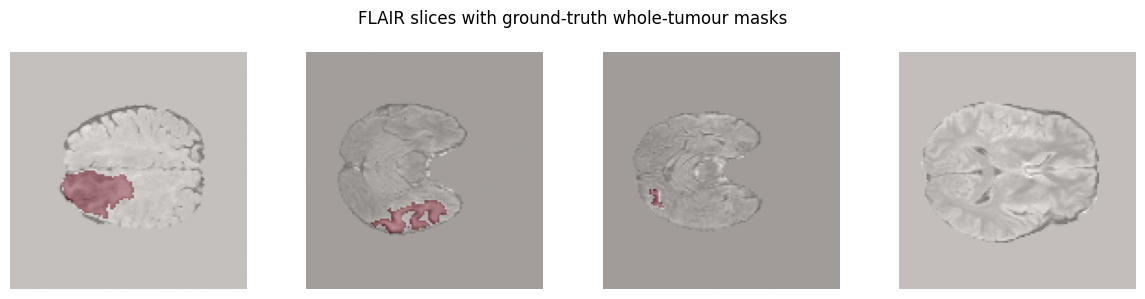

In [6]:
# Cell 6 — Dataset, data loaders and sample visualization


class BraTSSliceDataset(Dataset):
    def __init__(self, split_name: str, augment: bool = False, cache_size: int = 4):
        self.files = sorted((PROCESSED_ROOT / split_name).glob("*.npz"))
        if not self.files:
            raise FileNotFoundError(f"No processed files found for split: {split_name}")

        self.augment = augment
        self.cache_size = cache_size
        self.cache = OrderedDict()
        self.index = []
        self.file_metadata = []

        for file_index, path in enumerate(self.files):
            with np.load(path) as data:
                number_of_slices = int(data["images"].shape[0])
                slice_indices = data["slice_indices"].astype(int).tolist()
                has_tumour = data["has_tumour"].astype(bool).tolist()

            case_id = path.stem
            self.file_metadata.append((case_id, slice_indices, has_tumour))
            self.index.extend((file_index, slice_index) for slice_index in range(number_of_slices))

    def __len__(self):
        return len(self.index)

    def _load_file(self, file_index: int):
        if file_index in self.cache:
            self.cache.move_to_end(file_index)
            return self.cache[file_index]

        with np.load(self.files[file_index]) as data:
            value = (
                data["images"].astype(np.float32),
                data["masks"].astype(np.float32),
            )

        self.cache[file_index] = value
        if len(self.cache) > self.cache_size:
            self.cache.popitem(last=False)
        return value

    @staticmethod
    def _augment(image: np.ndarray, mask: np.ndarray):
        if random.random() < 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()
        if random.random() < 0.5:
            image = np.flipud(image).copy()
            mask = np.flipud(mask).copy()
        if random.random() < 0.25:
            image = image * random.uniform(0.90, 1.10) + random.uniform(-0.10, 0.10)
        return image, mask

    def __getitem__(self, item: int):
        file_index, local_slice_index = self.index[item]
        images, masks = self._load_file(file_index)
        image = images[local_slice_index].copy()
        mask = masks[local_slice_index].copy()

        if self.augment:
            image, mask = self._augment(image, mask)

        case_id, original_slice_indices, tumour_flags = self.file_metadata[file_index]
        return {
            "image": torch.from_numpy(image).unsqueeze(0).float(),
            "mask": torch.from_numpy(mask).unsqueeze(0).float(),
            "case_id": case_id,
            "slice_idx": int(original_slice_indices[local_slice_index]),
            "has_tumour": bool(tumour_flags[local_slice_index]),
        }


train_dataset = BraTSSliceDataset("train", augment=True)
val_dataset = BraTSSliceDataset("val", augment=False)
test_dataset = BraTSSliceDataset("test", augment=False)

loader_arguments = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": NUM_WORKERS > 0,
}

train_loader = DataLoader(train_dataset, shuffle=True, **loader_arguments)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_arguments)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_arguments)

print("Train slices:", len(train_dataset))
print("Validation slices:", len(val_dataset))
print("Test slices:", len(test_dataset))

sample_batch = next(iter(train_loader))
number_to_show = min(4, sample_batch["image"].shape[0])
fig, axes = plt.subplots(1, number_to_show, figsize=(3 * number_to_show, 3))
if number_to_show == 1:
    axes = [axes]

for index in range(number_to_show):
    axes[index].imshow(sample_batch["image"][index, 0].numpy(), cmap="gray")
    axes[index].imshow(sample_batch["mask"][index, 0].numpy(), cmap="Reds", alpha=0.45)
    axes[index].axis("off")

plt.suptitle("FLAIR slices with ground-truth whole-tumour masks")
plt.tight_layout()
plt.show()


In [7]:
# Cell 7 — 2D U-Net, loss functions and metric helpers


class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        return self.conv(torch.cat([skip, x], dim=1))


class UNet2D(nn.Module):
    def __init__(self, in_channels: int = 1, out_channels: int = 1, base: int = 16):
        super().__init__()
        self.input_block = DoubleConv(in_channels, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.down4 = Down(base * 8, base * 16)
        self.dropout = nn.Dropout2d(0.30)
        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)
        self.output = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        x1 = self.input_block(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.dropout(self.down4(x4))
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.output(x)


class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits).flatten(start_dim=1)
        targets = targets.flatten(start_dim=1)
        intersection = (probabilities * targets).sum(dim=1)
        denominator = probabilities.sum(dim=1) + targets.sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        return 1.0 - dice.mean()


class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        return 0.5 * self.dice(logits, targets) + 0.5 * self.bce(logits, targets)


def get_loss(loss_name: str):
    if loss_name == "dice":
        return DiceLoss()
    if loss_name == "dice_bce":
        return DiceBCELoss()
    raise ValueError(f"Unknown loss: {loss_name}")


def confusion_counts(prediction: torch.Tensor, target: torch.Tensor):
    prediction = prediction.bool()
    target = target.bool()
    tp = int(torch.logical_and(prediction, target).sum().item())
    fp = int(torch.logical_and(prediction, ~target).sum().item())
    fn = int(torch.logical_and(~prediction, target).sum().item())
    tn = int(torch.logical_and(~prediction, ~target).sum().item())
    return tp, fp, fn, tn


def metrics_from_counts(tp: int, fp: int, fn: int, tn: int, epsilon: float = 1e-8):
    return {
        "dice": (2.0 * tp) / (2.0 * tp + fp + fn + epsilon),
        "iou": tp / (tp + fp + fn + epsilon),
        "sensitivity": tp / (tp + fn + epsilon),
        "precision": tp / (tp + fp + epsilon),
        "specificity": tn / (tn + fp + epsilon),
    }


model_test = UNet2D(base=BASE_FILTERS).to(DEVICE)
with torch.no_grad():
    output_test = model_test(torch.randn(2, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))
print("Model output shape:", tuple(output_test.shape))
print("Trainable parameters:", f"{sum(p.numel() for p in model_test.parameters() if p.requires_grad):,}")
del model_test, output_test
torch.cuda.empty_cache()


Model output shape: (2, 1, 128, 128)
Trainable parameters: 1,942,289


In [8]:
# Cell 8 — Training with mixed precision, early stopping and epoch-by-epoch resume


def safe_torch_load(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def run_training_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_total = 0.0
    sample_total = 0
    counts = np.zeros(4, dtype=np.int64)

    progress = tqdm(loader, desc="Training", leave=False)
    for batch in progress:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        predictions = torch.sigmoid(logits.detach()) >= 0.5
        counts += np.asarray(confusion_counts(predictions, masks >= 0.5), dtype=np.int64)
        batch_size = images.size(0)
        loss_total += float(loss.detach()) * batch_size
        sample_total += batch_size
        progress.set_postfix(loss=f"{loss_total / max(sample_total, 1):.4f}")

    return loss_total / max(sample_total, 1), metrics_from_counts(*counts.tolist())


@torch.no_grad()
def run_validation_epoch(model, loader, criterion):
    model.eval()
    loss_total = 0.0
    sample_total = 0
    counts = np.zeros(4, dtype=np.int64)

    for batch in tqdm(loader, desc="Validation", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(images)
            loss = criterion(logits, masks)

        predictions = torch.sigmoid(logits) >= 0.5
        counts += np.asarray(confusion_counts(predictions, masks >= 0.5), dtype=np.int64)
        batch_size = images.size(0)
        loss_total += float(loss) * batch_size
        sample_total += batch_size

    return loss_total / max(sample_total, 1), metrics_from_counts(*counts.tolist())


def train_experiment(experiment_name: str, loss_name: str):
    print("\n" + "=" * 72)
    print(f"Experiment: {experiment_name} | Loss: {loss_name}")
    print("=" * 72)

    model = UNet2D(base=BASE_FILTERS).to(DEVICE)
    criterion = get_loss(loss_name)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    best_path = CHECKPOINT_DIR / f"{experiment_name}_best.pt"
    latest_path = CHECKPOINT_DIR / f"{experiment_name}_latest.pt"
    history_path = RESULTS_DIR / f"{experiment_name}_history.csv"

    history = []
    start_epoch = 1
    best_val_dice = -1.0
    patience_counter = 0

    if latest_path.exists():
        checkpoint = safe_torch_load(latest_path, DEVICE)
        if checkpoint.get("configuration") == CONFIG:
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            scaler.load_state_dict(checkpoint["scaler_state_dict"])
            history = checkpoint.get("history", [])
            start_epoch = int(checkpoint["epoch"]) + 1
            best_val_dice = float(checkpoint.get("best_val_dice", -1.0))
            patience_counter = int(checkpoint.get("patience_counter", 0))

            if checkpoint.get("finished", False):
                print("This experiment is already complete. Using saved results.")
                return pd.DataFrame(history), best_path

            print(f"Resuming from epoch {start_epoch}.")
        else:
            print("An old checkpoint with different settings was ignored.")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        epoch_start = time.time()
        train_loss, train_metrics = run_training_epoch(
            model, train_loader, criterion, optimizer, scaler
        )
        val_loss, val_metrics = run_validation_epoch(model, val_loader, criterion)
        scheduler.step(val_metrics["dice"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_dice": train_metrics["dice"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_precision": val_metrics["precision"],
            "learning_rate": optimizer.param_groups[0]["lr"],
            "seconds": time.time() - epoch_start,
        }
        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        improved = val_metrics["dice"] > best_val_dice
        if improved:
            best_val_dice = val_metrics["dice"]
            patience_counter = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_dice": best_val_dice,
                    "experiment_name": experiment_name,
                    "loss_name": loss_name,
                    "configuration": CONFIG,
                },
                best_path,
            )
        else:
            patience_counter += 1

        latest_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_dice": best_val_dice,
            "patience_counter": patience_counter,
            "history": history,
            "experiment_name": experiment_name,
            "loss_name": loss_name,
            "configuration": CONFIG,
            "finished": False,
        }
        torch.save(latest_state, latest_path)

        marker = " * best" if improved else ""
        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
            f"train Dice {train_metrics['dice']:.4f} | val Dice {val_metrics['dice']:.4f}"
            f"{marker}"
        )

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            latest_state["finished"] = True
            torch.save(latest_state, latest_path)
            break
    else:
        if latest_path.exists():
            latest_state = safe_torch_load(latest_path, DEVICE)
            latest_state["finished"] = True
            torch.save(latest_state, latest_path)

    del model
    torch.cuda.empty_cache()
    return pd.DataFrame(history), best_path


In [9]:
# Cell 9 — Experiment 1: Dice loss

dice_history, dice_checkpoint = train_experiment(
    experiment_name="exp1_dice_loss",
    loss_name="dice",
)
print("Best Dice-loss checkpoint:", dice_checkpoint)
display(dice_history.tail())



Experiment: exp1_dice_loss | Loss: dice


Training:   0%|          | 0/1963 [00:00<?, ?it/s]

Validation:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.7295 | val loss 0.6772 | train Dice 0.2013 | val Dice 0.0667 * best


Training:   0%|          | 0/1963 [00:00<?, ?it/s]

...

Epoch 09/10 | train loss 0.5786 | val loss 0.6293 | train Dice 0.8280 | val Dice 0.8302


Training:   0%|          | 0/1963 [00:00<?, ?it/s]

Validation:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.5769 | val loss 0.6256 | train Dice 0.8291 | val Dice 0.8301
Best Dice-loss checkpoint: /kaggle/working/brats_2d_unet_outputs_final/checkpoints/exp1_dice_loss_best.pt


,epoch,train_loss,val_loss,train_dice,val_dice,val_iou,val_sensitivity,val_precision,learning_rate,seconds
5,6,0.581659,0.627242,0.678100,0.803014,0.670863,0.879763,0.738582,0.0002,419.268130
6,7,0.580572,0.630671,0.803331,0.772639,0.629512,0.886041,0.684971,0.0002,419.953978
7,8,0.579351,0.627345,0.825902,0.838495,0.721904,0.880073,0.800669,0.0002,419.056948
8,9,0.578573,0.629335,0.828018,0.830155,0.709628,0.865742,0.797379,0.0002,416.579137
9,10,0.576863,0.625571,0.829149,0.830148,0.709618,0.875109,0.789582,0.0002,419.507181


In [10]:
# Cell 10 — Experiment 2: Dice+BCE loss

dice_bce_history, dice_bce_checkpoint = train_experiment(
    experiment_name="exp2_dice_bce_loss",
    loss_name="dice_bce",
)
print("Best Dice+BCE checkpoint:", dice_bce_checkpoint)
display(dice_bce_history.tail())



Experiment: exp2_dice_bce_loss | Loss: dice_bce


Training:   0%|          | 0/1963 [00:00<?, ?it/s]

Validation:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.5247 | val loss 0.3972 | train Dice 0.7728 | val Dice 0.7999 * best


Training:   0%|          | 0/1963 [00:00<?, ?it/s]

...

Epoch 07/10 | train loss 0.2949 | val loss 0.3197 | train Dice 0.8732 | val Dice 0.8686


Training:   0%|          | 0/1963 [00:00<?, ?it/s]

Validation:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch 08/10 | train loss 0.2945 | val loss 0.3222 | train Dice 0.8742 | val Dice 0.8475
Early stopping at epoch 8.
Best Dice+BCE checkpoint: /kaggle/working/brats_2d_unet_outputs_final/checkpoints/exp2_dice_bce_loss_best.pt


,epoch,train_loss,val_loss,train_dice,val_dice,val_iou,val_sensitivity,val_precision,learning_rate,seconds
3,4,0.300232,0.325053,0.861310,0.850501,0.739888,0.838089,0.863286,0.0002,419.986950
4,5,0.297435,0.321258,0.866772,0.877587,0.781875,0.894450,0.861347,0.0002,419.980107
5,6,0.296253,0.321666,0.870038,0.864057,0.760651,0.897476,0.833036,0.0002,420.317403
6,7,0.294949,0.319677,0.873217,0.868594,0.767712,0.891390,0.846935,0.0002,420.946648
7,8,0.294479,0.322177,0.874197,0.847486,0.735337,0.890342,0.808566,0.0001,420.984241


In [11]:
# Cell 11 — Final evaluation: patient-level, tumour-slice and lesion-size results

EXPERIMENTS = {
    "exp1_dice_loss": dice_checkpoint,
    "exp2_dice_bce_loss": dice_bce_checkpoint,
}


def load_best_model(checkpoint_path: Path):
    checkpoint = safe_torch_load(checkpoint_path, DEVICE)
    model = UNet2D(base=BASE_FILTERS).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


@torch.no_grad()
def evaluate_model(experiment_name: str, checkpoint_path: Path):
    model = load_best_model(checkpoint_path)
    patient_counts = defaultdict(lambda: np.zeros(4, dtype=np.int64))
    slice_rows = []

    for batch in tqdm(test_loader, desc=f"Testing {experiment_name}"):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(images)

        predictions = torch.sigmoid(logits) >= 0.5
        targets = masks >= 0.5

        for index, case_id in enumerate(batch["case_id"]):
            counts = np.asarray(
                confusion_counts(
                    predictions[index:index + 1],
                    targets[index:index + 1],
                ),
                dtype=np.int64,
            )
            patient_counts[case_id] += counts
            slice_metrics = metrics_from_counts(*counts.tolist())
            slice_rows.append(
                {
                    "experiment": experiment_name,
                    "case_id": case_id,
                    "slice_idx": int(batch["slice_idx"][index]),
                    "has_tumour": bool(batch["has_tumour"][index]),
                    "ground_truth_pixels": int(counts[0] + counts[2]),
                    "predicted_pixels": int(counts[0] + counts[1]),
                    **slice_metrics,
                }
            )

    patient_rows = []
    for case_id, counts in sorted(patient_counts.items()):
        metrics = metrics_from_counts(*counts.tolist())
        patient_rows.append(
            {
                "experiment": experiment_name,
                "case_id": case_id,
                "ground_truth_pixels": int(counts[0] + counts[2]),
                "predicted_pixels": int(counts[0] + counts[1]),
                "false_positive_pixels": int(counts[1]),
                "false_negative_pixels": int(counts[2]),
                **metrics,
            }
        )

    del model
    torch.cuda.empty_cache()
    return pd.DataFrame(patient_rows), pd.DataFrame(slice_rows)


patient_frames = []
slice_frames = []
for experiment_name, checkpoint_path in EXPERIMENTS.items():
    patient_frame, slice_frame = evaluate_model(experiment_name, checkpoint_path)
    patient_frames.append(patient_frame)
    slice_frames.append(slice_frame)

patient_results = pd.concat(patient_frames, ignore_index=True)
slice_results = pd.concat(slice_frames, ignore_index=True)

# Use the same patient-size categories for both models, based on ground truth.
size_reference = (
    patient_results[patient_results["experiment"] == "exp1_dice_loss"]
    [["case_id", "ground_truth_pixels"]]
    .drop_duplicates("case_id")
    .copy()
)

if len(size_reference) >= 3:
    size_reference["lesion_size"] = pd.qcut(
        size_reference["ground_truth_pixels"].rank(method="first"),
        q=3,
        labels=["small", "medium", "large"],
    )
else:
    size_reference["lesion_size"] = "insufficient_cases"

patient_results = patient_results.merge(
    size_reference[["case_id", "lesion_size"]],
    on="case_id",
    how="left",
)

metric_columns = ["dice", "iou", "sensitivity", "precision", "specificity"]
model_comparison = (
    patient_results.groupby("experiment")[metric_columns]
    .agg(["mean", "std"])
)
model_comparison.columns = [f"{metric}_{stat}" for metric, stat in model_comparison.columns]
model_comparison = model_comparison.reset_index()

# Empty slices can inflate scores, so report tumour-containing slices separately.
tumour_slice_comparison = (
    slice_results[slice_results["has_tumour"]]
    .groupby("experiment")[metric_columns]
    .mean()
    .reset_index()
)

lesion_size_analysis = (
    patient_results.groupby(["experiment", "lesion_size"], observed=False)[metric_columns]
    .mean()
    .reset_index()
)

patient_results.to_csv(RESULTS_DIR / "patient_test_metrics.csv", index=False)
slice_results.to_csv(RESULTS_DIR / "per_slice_test_metrics.csv", index=False)
model_comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
tumour_slice_comparison.to_csv(RESULTS_DIR / "tumour_slice_comparison.csv", index=False)
lesion_size_analysis.to_csv(RESULTS_DIR / "lesion_size_analysis.csv", index=False)

print("Patient-level model comparison:")
display(model_comparison)
print("Tumour-containing slice comparison:")
display(tumour_slice_comparison)
print("Patient lesion-size analysis:")
display(lesion_size_analysis)


Testing exp1_dice_loss:   0%|          | 0/467 [00:00<?, ?it/s]

Testing exp2_dice_bce_loss:   0%|          | 0/467 [00:00<?, ?it/s]

Patient-level model comparison:


,experiment,dice_mean,dice_std,iou_mean,iou_std,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,specificity_std
0,exp1_dice_loss,0.772126,0.157290,0.651860,0.184409,0.865960,0.128929,0.722931,0.181475,0.996637,0.001884
1,exp2_dice_bce_loss,0.831887,0.096208,0.722609,0.129593,0.880641,0.116967,0.804010,0.114301,0.997702,0.001430


Tumour-containing slice comparison:


,experiment,dice,iou,sensitivity,precision,specificity
0,exp1_dice_loss,0.765610,0.672482,0.812311,0.770122,0.995983
1,exp2_dice_bce_loss,0.771527,0.678790,0.823816,0.768078,0.996117


Patient lesion-size analysis:


,experiment,lesion_size,dice,iou,sensitivity,precision,specificity
0,exp1_dice_loss,small,0.644531,0.495779,0.831224,0.548168,0.996702
1,exp1_dice_loss,medium,0.801217,0.684666,0.874809,0.765795,0.996274
2,exp1_dice_loss,large,0.872162,0.776861,0.892312,0.857087,0.996917
3,exp2_dice_bce_loss,small,0.764662,0.628935,0.845289,0.716428,0.998452
4,exp2_dice_bce_loss,medium,0.841529,0.735403,0.893155,0.815676,0.997145
5,exp2_dice_bce_loss,large,0.889978,0.804163,0.904136,0.880538,0.997479


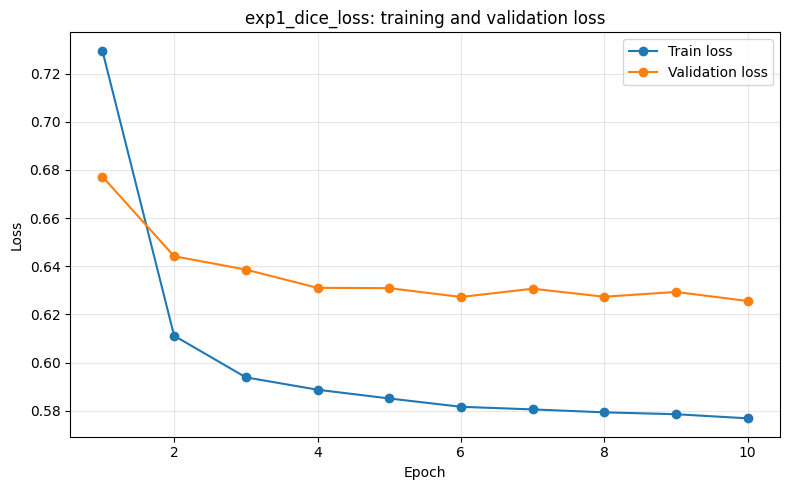

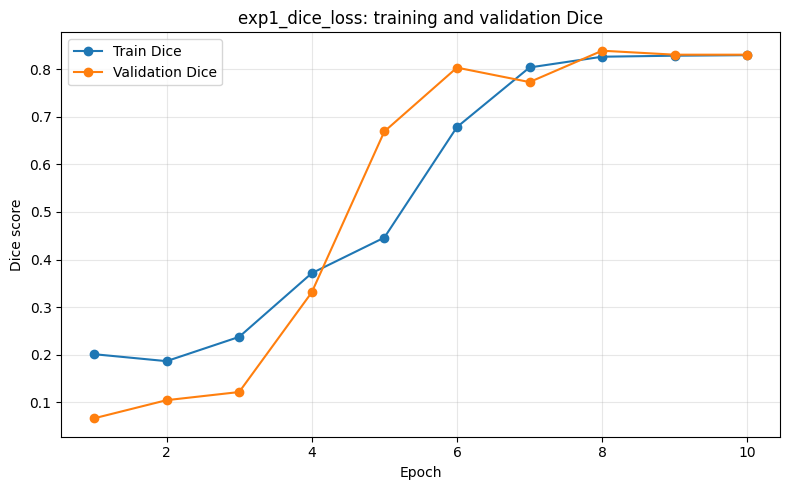

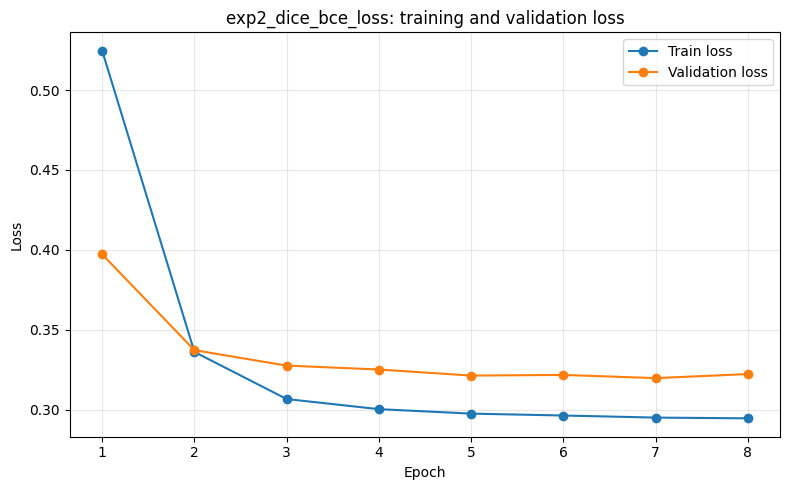

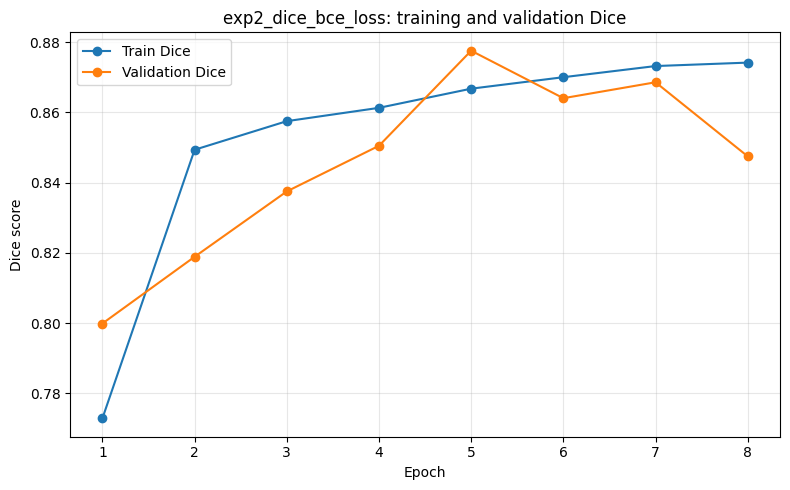

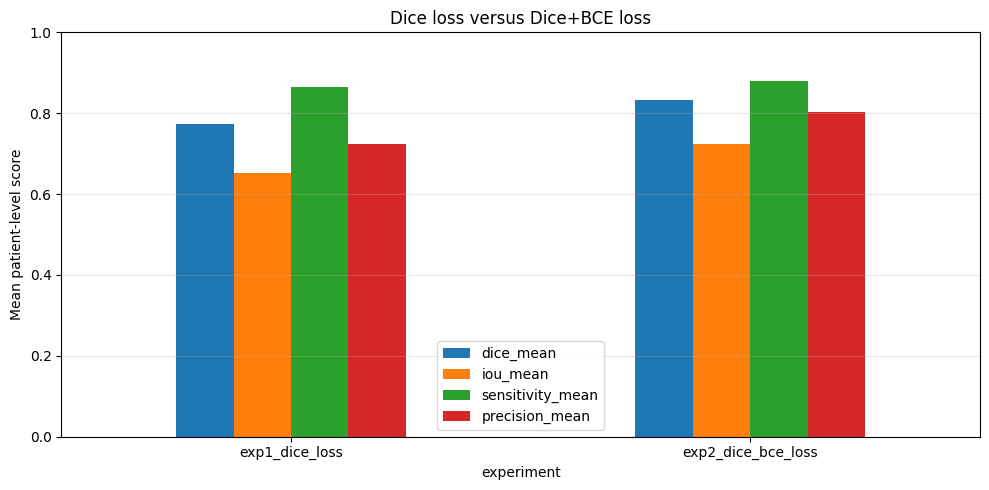

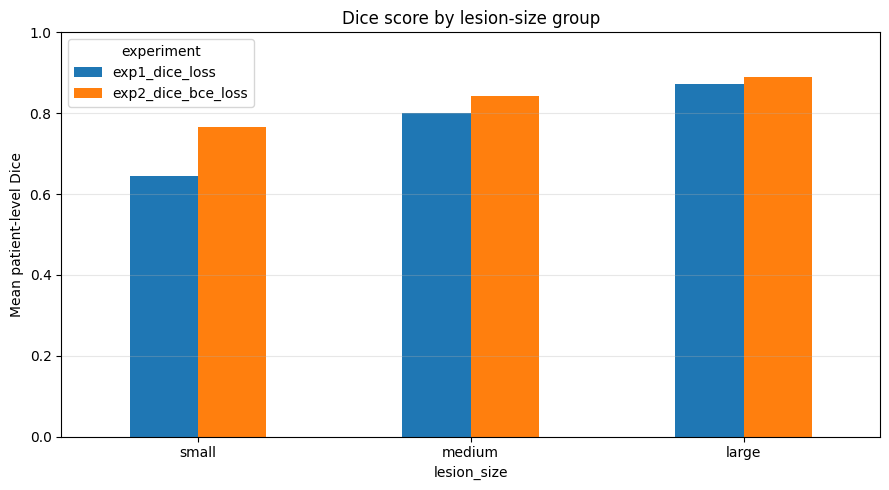

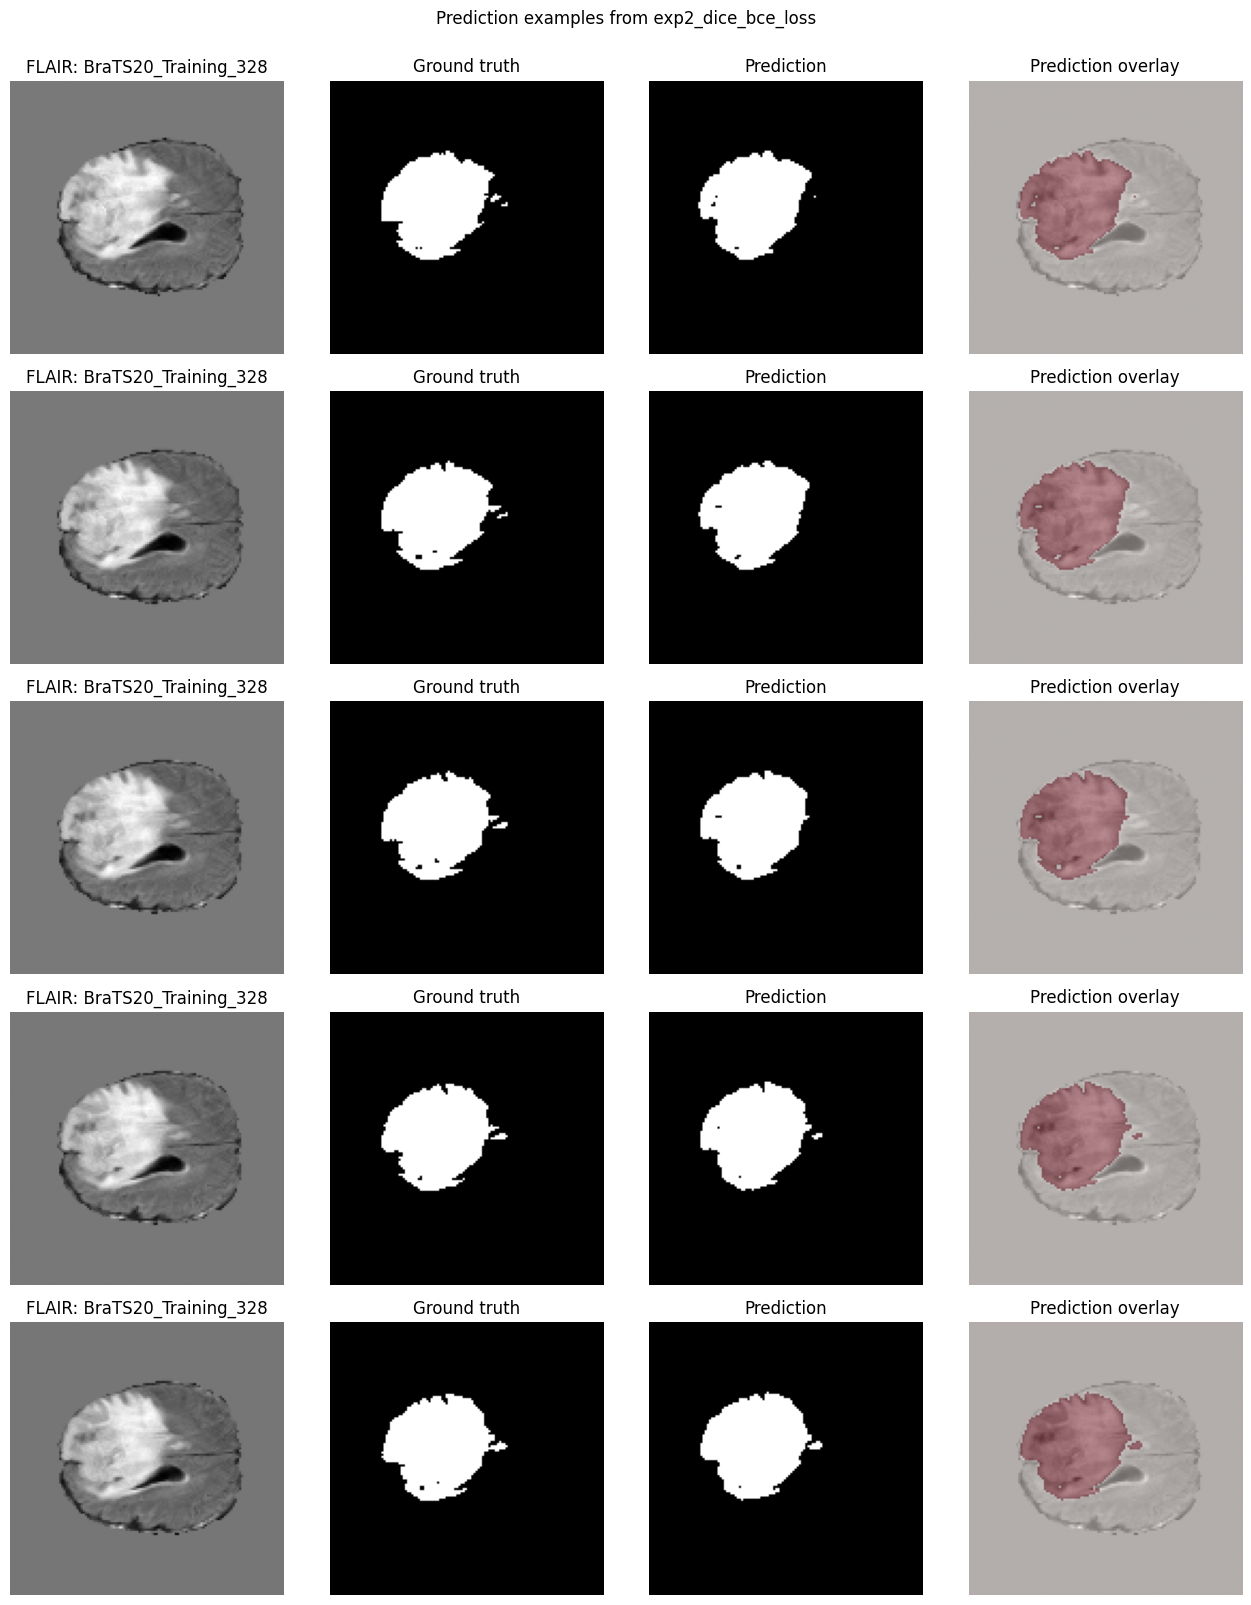

In [12]:
# Cell 12 — Training graphs, comparison charts and prediction examples


def plot_training_history(experiment_name: str):
    history = pd.read_csv(RESULTS_DIR / f"{experiment_name}_history.csv")

    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
    plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name}: training and validation loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    path = FIGURE_DIR / f"{experiment_name}_loss.png"
    plt.savefig(path, dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["train_dice"], marker="o", label="Train Dice")
    plt.plot(history["epoch"], history["val_dice"], marker="o", label="Validation Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice score")
    plt.title(f"{experiment_name}: training and validation Dice")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    path = FIGURE_DIR / f"{experiment_name}_dice.png"
    plt.savefig(path, dpi=150)
    plt.show()


for experiment_name in EXPERIMENTS:
    plot_training_history(experiment_name)

comparison_plot_data = model_comparison.set_index("experiment")
plot_columns = ["dice_mean", "iou_mean", "sensitivity_mean", "precision_mean"]
comparison_plot_data[plot_columns].plot(kind="bar", figsize=(10, 5))
plt.ylabel("Mean patient-level score")
plt.ylim(0, 1)
plt.title("Dice loss versus Dice+BCE loss")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", dpi=150)
plt.show()

lesion_pivot = lesion_size_analysis.pivot(index="lesion_size", columns="experiment", values="dice")
lesion_pivot = lesion_pivot.reindex(["small", "medium", "large"])
lesion_pivot.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Mean patient-level Dice")
plt.ylim(0, 1)
plt.title("Dice score by lesion-size group")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lesion_size_comparison.png", dpi=150)
plt.show()

# Select the model with the highest mean patient-level Dice.
best_experiment = model_comparison.sort_values("dice_mean", ascending=False).iloc[0]["experiment"]
best_model = load_best_model(EXPERIMENTS[best_experiment])

candidate_examples = []
for dataset_index in range(len(test_dataset)):
    item = test_dataset[dataset_index]
    tumour_area = float(item["mask"].sum())
    if tumour_area > 0:
        candidate_examples.append((tumour_area, dataset_index))

selected_examples = [index for _, index in sorted(candidate_examples, reverse=True)[:5]]

fig, axes = plt.subplots(len(selected_examples), 4, figsize=(13, 3.2 * len(selected_examples)))
if len(selected_examples) == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():
    for row, dataset_index in enumerate(selected_examples):
        item = test_dataset[dataset_index]
        image = item["image"].unsqueeze(0).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            prediction = torch.sigmoid(best_model(image))[0, 0].cpu().numpy() >= 0.5

        image_np = item["image"][0].numpy()
        mask_np = item["mask"][0].numpy()

        axes[row, 0].imshow(image_np, cmap="gray")
        axes[row, 0].set_title(f"FLAIR: {item['case_id']}")
        axes[row, 1].imshow(mask_np, cmap="gray")
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(prediction, cmap="gray")
        axes[row, 2].set_title("Prediction")
        axes[row, 3].imshow(image_np, cmap="gray")
        axes[row, 3].imshow(prediction, cmap="Reds", alpha=0.45)
        axes[row, 3].set_title("Prediction overlay")
        for column in range(4):
            axes[row, column].axis("off")

plt.suptitle(f"Prediction examples from {best_experiment}", y=1.0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "prediction_examples.png", dpi=150, bbox_inches="tight")
plt.show()

del best_model
torch.cuda.empty_cache()


In [13]:
# Cell 13 — Create a downloadable results archive

archive_base = Path("/kaggle/working") / f"brats_2d_unet_results_{RUN_MODE}"
archive_path = shutil.make_archive(str(archive_base), "zip", OUTPUT_ROOT)

print("Results folder:", OUTPUT_ROOT)
print("Downloadable ZIP:", archive_path)
print("\nImportant result files:")
for path in sorted(RESULTS_DIR.glob("*.csv")):
    print("-", path.name)
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)
for path in sorted(CHECKPOINT_DIR.glob("*_best.pt")):
    print("-", path.name)


Results folder: /kaggle/working/brats_2d_unet_outputs_final
Downloadable ZIP: /kaggle/working/brats_2d_unet_results_final.zip

Important result files:
- exp1_dice_loss_history.csv
- exp2_dice_bce_loss_history.csv
- lesion_size_analysis.csv
- model_comparison.csv
- patient_test_metrics.csv
- per_slice_test_metrics.csv
- preprocessing_summary.csv
- tumour_slice_comparison.csv
- exp1_dice_loss_dice.png
- exp1_dice_loss_loss.png
- exp2_dice_bce_loss_dice.png
- exp2_dice_bce_loss_loss.png
- lesion_size_comparison.png
- model_comparison.png
- prediction_examples.png
- exp1_dice_loss_best.pt
- exp2_dice_bce_loss_best.pt


In [14]:
# verify zip exists

import os

zip_path = "/kaggle/working/brats_2d_unet_results_final.zip"

print("Exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("Size:", os.path.getsize(zip_path) / (1024 ** 2), "MB")

Exists: True
Size: 55.86501216888428 MB


In [15]:
# create a clickable link

%cd /kaggle/working

from IPython.display import FileLink, display

display(FileLink("brats_2d_unet_results_final.zip"))

/kaggle/working


/kaggle/working/brats_2d_unet_results_final.zip